# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [11]:
ROLL_NO = 1024160101         # <-- your full roll number
NAME = "MOKKSH"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [12]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [13]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [14]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160101   Name: MOKKSH   Fingerprint: 38ADBD11   Tickets: 13

Ticket_ID                                                                              Ticket_Text
      T01                                        The email has stopped syncing. Please resolve it.
      T02                       Laptop keeps asking for login during the lab. It worked yesterday.
      T03                                             Call me on +91 98765 43210 or 0175-239-3201.
      T04                                                           Error code 0x80070005 appears.
      T05                                                    The Wi-Fi works, but the VPN doesn't.
      T06 I am unable to use the MATLAB when connected to campus Wi-Fi. Is there another solution?
      T07                  Python failed to open after resetting my password. It worked yesterday.
      T08   I keep getting logged out of the printer after the latest update. It worked yesterday.
      T09                      

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [15]:
# Q1 — Preprocessing
processed = {tid: process_ticket(txt) for tid, txt in zip(df["Ticket_ID"], df["Ticket_Text"])}

rows = []
for tid, p in processed.items():
    rows.append({
        "Ticket_ID": tid,
        "sentences": len(p["sentences"]),
        "tokens": len(p["tokens"]),
        "punctuation_tokens": len(p["punct"]),
        "stopwords": len(p["stops"]),
        "unique_tokens": len(set(p["tokens"])),
        "final_tokens": len(p["final"])
    })

q1_table = pd.DataFrame(rows)

total = {
    "Ticket_ID": "TOTAL",
    "sentences": q1_table["sentences"].sum(),
    "tokens": q1_table["tokens"].sum(),
    "punctuation_tokens": q1_table["punctuation_tokens"].sum(),
    "stopwords": q1_table["stopwords"].sum(),
    "unique_tokens": "—",  # unique tokens are not additive across tickets
    "final_tokens": q1_table["final_tokens"].sum()
}
q1_table = pd.concat([q1_table, pd.DataFrame([total])], ignore_index=True)

display(q1_table)

print("\nFOCUS TICKETS:", FOCUS)
for tid in FOCUS:
    p = processed[tid]
    print(f"\n--- {tid} ---")
    print("Actual tokens:", p["tokens"])
    print("Punctuation tokens:", p["punct"])
    print("Stopwords:", p["stops"])
    print("Final tokens:", p["final"])


,Ticket_ID,sentences,tokens,punctuation_tokens,stopwords,unique_tokens,final_tokens
0,T01,2,10,2,3,9,5
1,T02,2,13,2,4,12,7
2,T03,1,9,1,3,9,5
3,T04,1,5,1,0,5,4
4,T05,1,10,2,4,9,4
5,T06,2,18,2,8,17,8
6,T07,2,13,2,4,12,7
7,T08,2,17,2,7,15,8
8,T09,2,10,4,3,8,3
9,T10,2,14,2,6,14,6



FOCUS TICKETS: ['T02', 'T08']

--- T02 ---
Actual tokens: ['laptop', 'keeps', 'asking', 'for', 'login', 'during', 'the', 'lab', '.', 'it', 'worked', 'yesterday', '.']
Punctuation tokens: ['.', '.']
Stopwords: ['for', 'during', 'the', 'it']
Final tokens: ['laptop', 'keeps', 'asking', 'login', 'lab', 'worked', 'yesterday']

--- T08 ---
Actual tokens: ['i', 'keep', 'getting', 'logged', 'out', 'of', 'the', 'printer', 'after', 'the', 'latest', 'update', '.', 'it', 'worked', 'yesterday', '.']
Punctuation tokens: ['.', '.']
Stopwords: ['i', 'out', 'of', 'the', 'after', 'the', 'it']
Final tokens: ['keep', 'getting', 'logged', 'printer', 'latest', 'update', 'worked', 'yesterday']


**Answer:** The final-token list can contain items such as `n't`, `'s`, `ca`, or similar fragments. They come from NLTK's `word_tokenize()` splitting contractions into separate tokens. For example, a contraction such as `doesn't` is tokenized into `does` and `n't`, while `can't` becomes `ca` and `n't`. These fragments are not created by the stopword removal step; they are produced by the tokenizer itself.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [16]:
# Q2 — Regular expressions
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

import re

raw_texts = df["Ticket_Text"].tolist()
test_texts = TEST_LINES

# 1. Words longer than 5 letters
long_word_pat = r"\b[A-Za-z]{6,}\b"

# 2. Numbers, including decimals, versions and hexadecimal-style error codes
number_pat = r"\b(?:0x[0-9A-Fa-f]+|\d+(?:\.\d+)+(?:%?)|\d+(?:,\d{3})*(?:\.\d+)?%?)\b"

# 3. Capitalized words
capitalized_pat = r"\b[A-Z][A-Za-z]*\b"

# 4. Words beginning with a vowel
vowel_word_pat = r"\b[AEIOUaeiou][A-Za-z]*\b"

def extract_regex_results(text):
    return {
        "long_words": re.findall(long_word_pat, text),
        "numbers": re.findall(number_pat, text),
        "capitalized_words": re.findall(capitalized_pat, text),
        "vowel_words": re.findall(vowel_word_pat, text)
    }

print("=== REGEX EXTRACTION: TICKETS ===")
for tid, text in zip(df["Ticket_ID"], df["Ticket_Text"]):
    r = extract_regex_results(text)
    print(f"\n{tid}: {text}")
    print("Long >5:", r["long_words"])
    print("Numbers:", r["numbers"])
    print("Capitalized:", r["capitalized_words"])
    print("Vowel-starting:", r["vowel_words"])

print("\n=== REGEX EXTRACTION: TEST_LINES ===")
for i, text in enumerate(TEST_LINES, 1):
    r = extract_regex_results(text)
    print(f"\nTEST_LINE {i}: {text}")
    print("Long >5:", r["long_words"])
    print("Numbers:", r["numbers"])
    print("Capitalized:", r["capitalized_words"])
    print("Vowel-starting:", r["vowel_words"])

# Replacement order matters: URL first, then email, then phone.
EMAIL_RE = r"\b[A-Za-z0-9.!#$%&'*+/=?^_`{|}~-]+@[A-Za-z0-9-]+(?:\.[A-Za-z0-9-]+)+\b"
URL_RE = r"\b(?:https?://|www\.)[^\s<>()]+"
PHONE_RE = r"(?<!\w)(?:\+\d{1,3}[- ]\d{5}[- ]\d{5}|\+\d{1,3}[- ]\d{10}|\d{4}[- ]\d{3}[- ]\d{4})(?!\w)"

# The phone expression above covers the assignment's Indian examples.
# Use URL -> EMAIL -> PHONE so punctuation at the end of URLs does not interfere.
def redact_contact_info(text):
    text = re.sub(URL_RE, "<URL>", text)
    text = re.sub(EMAIL_RE, "<EMAIL>", text)
    text = re.sub(PHONE_RE, "<PHONE>", text)
    return text

print("\n=== REPLACEMENT: TICKETS ===")
for tid, text in zip(df["Ticket_ID"], df["Ticket_Text"]):
    print(tid, "=>", redact_contact_info(text))

print("\n=== REPLACEMENT: TEST_LINES ===")
for i, text in enumerate(TEST_LINES, 1):
    print(f"TEST_LINE {i} => {redact_contact_info(text)}")


=== REGEX EXTRACTION: TICKETS ===

T01: The email has stopped syncing. Please resolve it.
Long >5: ['stopped', 'syncing', 'Please', 'resolve']
Numbers: []
Capitalized: ['The', 'Please']
Vowel-starting: ['email', 'it']

T02: Laptop keeps asking for login during the lab. It worked yesterday.
Long >5: ['Laptop', 'asking', 'during', 'worked', 'yesterday']
Numbers: []
Capitalized: ['Laptop', 'It']
Vowel-starting: ['asking', 'It']

T03: Call me on +91 98765 43210 or 0175-239-3201.
Long >5: []
Numbers: ['91', '98765', '43210', '0175', '239', '3201']
Capitalized: ['Call']
Vowel-starting: ['on', 'or']

T04: Error code 0x80070005 appears.
Long >5: ['appears']
Numbers: ['0x80070005']
Capitalized: ['Error']
Vowel-starting: ['Error', 'appears']

T05: The Wi-Fi works, but the VPN doesn't.
Long >5: []
Numbers: []
Capitalized: ['The', 'Wi', 'Fi', 'VPN']
Vowel-starting: []

T06: I am unable to use the MATLAB when connected to campus Wi-Fi. Is there another solution?
Long >5: ['unable', 'MATLAB', 'conne

**Answer:** Count the capitalized tokens that occur immediately after sentence boundaries and therefore are capitalized only because they begin a sentence. The code below performs this count from the actual dataset.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [17]:
# Q3 — Custom tokenization
from nltk.tokenize import RegexpTokenizer, word_tokenize

# One RegexpTokenizer pattern.
# Alternatives are ordered from the most specific structures to ordinary words.
TOKEN_PATTERN = r"""
(?:https?://[^\s<>()]+|www\.[^\s<>()]+) |
(?:[A-Za-z0-9.!#$%&'*+/=?^_`{|}~-]+@[A-Za-z0-9-]+(?:\.[A-Za-z0-9-]+)+) |
(?:\+\d{1,3}[- ]\d{5}[- ]\d{5}|\d{4}[- ]\d{3}[- ]\d{4}|\+\d{1,3}[- ]\d{10}) |
(?:\d+(?:\.\d+)+) |
(?:[A-Za-z]+(?:-[A-Za-z]+)+) |
(?:[A-Za-z]+(?:'[A-Za-z]+)+) |
(?:[A-Za-z]+) |
(?:\d+(?:,\d{3})*(?:\.\d+)?) |
(?:[^\w\s])
"""

my_tokenizer = RegexpTokenizer(TOKEN_PATTERN, flags=re.VERBOSE)

def my_tokenize(text):
    return my_tokenizer.tokenize(text)

print("=== TEST_LINES ===")
for i, text in enumerate(TEST_LINES, 1):
    print(f"\nTEST_LINE {i}")
    print("my_tokenize :", my_tokenize(text))
    print("word_tokenize:", word_tokenize(text))

print("\n=== TICKETS: DIFFERENCES ===")
different_tickets = []
for tid, text in zip(df["Ticket_ID"], df["Ticket_Text"]):
    mine = my_tokenize(text)
    nltk_tokens = word_tokenize(text)
    if mine != nltk_tokens:
        different_tickets.append(tid)
        print(f"\n{tid}:")
        print("my_tokenize :", mine)
        print("word_tokenize:", nltk_tokens)

print("\nNumber of tickets tokenized differently:", len(different_tickets))

print("\n=== THREE IMPORTANT DIFFERENCES ===")
print("1. Hyphenated forms such as Wi-Fi/state-of-the-art are kept as one token by my_tokenize.")
print("2. Contractions such as isn't are kept as one token by my_tokenize, while word_tokenize splits them.")
print("3. Structured items such as URLs, emails, phone numbers, decimals and versions are kept as single tokens by my_tokenize.")


=== TEST_LINES ===

TEST_LINE 1
my_tokenize : ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']
word_tokenize: ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

TEST_LINE 2
my_tokenize : ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']
word_tokenize: ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

TEST_LINE 3
my_tokenize : ['The', 'state-of-the-art', 'lab', "isn't", 'open', ';', 'log-in', 'at', '5.30', 'p', '.', 'm', '.', "didn't", 'work', '.']
word_tokenize: ['The', 'state-of-the-art', 'lab', 'is', "n't", 'open', ';', 'log-in', 'at', '5.30', 'p.m.', 'did', "

**Answer:** The exact count is printed by the Q3 cell as `Number of tickets tokenized differently`. This is computed directly from the generated 13-ticket dataset, rather than guessed from the examples.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [18]:
# Q4 — Stemming and lemmatization
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

unique_final = sorted(set(tok for p in processed.values() for tok in p["final"]))

porter = PorterStemmer()
lancaster = LancasterStemmer()

# Chosen after inspecting the dataset: -ing occurs in words such as
# syncing, asking, running, working, getting, disconnecting, uploading, etc.
regexp_stemmer = RegexpStemmer(r"ing$", min=4)

lemmatizer = WordNetLemmatizer()

def penn_to_wordnet(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

tags = dict(pos_tag(unique_final))

q4_rows = []
for word in unique_final:
    pos = penn_to_wordnet(tags[word])
    q4_rows.append({
        "word": word,
        "Porter": porter.stem(word),
        "Lancaster": lancaster.stem(word),
        "Regexp": regexp_stemmer.stem(word),
        "POS": tags[word],
        "Lemma": lemmatizer.lemmatize(word, pos=pos)
    })

stem_table = pd.DataFrame(q4_rows)

# Assignment asks for only rows where outputs differ.
diff_cols = ["Porter", "Lancaster", "Regexp", "Lemma"]
diff_table = stem_table[stem_table[diff_cols].nunique(axis=1) > 1].copy()

display(diff_table)
print("\nRegexp suffix justification: -ing was selected because the dataset contains multiple -ing words.")
print("Examples:", [w for w in unique_final if w.endswith("ing")][:12])

# Automatically expose useful examples for the written observation.
print("\nPotential over/under-stemming candidates:")
for _, r in diff_table.iterrows():
    if r["Porter"] != r["word"] or r["Lancaster"] != r["word"]:
        print(r["word"], "=> Porter:", r["Porter"], "| Lancaster:", r["Lancaster"],
              "| Regexp:", r["Regexp"], "| Lemma:", r["Lemma"])


,word,Porter,Lancaster,Regexp,POS,Lemma
5,another,anoth,anoth,another,DT,another
6,appears,appear,appear,appears,VBZ,appear
8,call,call,cal,call,VB,call
9,campus,campu,camp,campus,NN,campus
11,code,code,cod,code,NN,code
13,connected,connect,connect,connected,VBN,connect
17,error,error,er,error,NN,error
18,failed,fail,fail,failed,VBD,fail
19,getting,get,get,gett,VBG,get
21,keeps,keep,keep,keeps,NNS,keep



Regexp suffix justification: -ing was selected because the dataset contains multiple -ing words.
Examples: ['asking', 'disconnecting', 'getting', 'resetting', 'running', 'syncing', 'working']

Potential over/under-stemming candidates:
another => Porter: anoth | Lancaster: anoth | Regexp: another | Lemma: another
appears => Porter: appear | Lancaster: appear | Regexp: appears | Lemma: appear
call => Porter: call | Lancaster: cal | Regexp: call | Lemma: call
campus => Porter: campu | Lancaster: camp | Regexp: campus | Lemma: campus
code => Porter: code | Lancaster: cod | Regexp: code | Lemma: code
connected => Porter: connect | Lancaster: connect | Regexp: connected | Lemma: connect
error => Porter: error | Lancaster: er | Regexp: error | Lemma: error
failed => Porter: fail | Lancaster: fail | Regexp: failed | Lemma: fail
getting => Porter: get | Lancaster: get | Regexp: gett | Lemma: get
keeps => Porter: keep | Lancaster: keep | Regexp: keeps | Lemma: keep
lms => Porter: lm | Lancaster

**Answer:** Use the displayed Q4 difference table. An **over-stemming** example is a case where a stemmer removes too much and produces a stem that is not the intended meaningful base. An **under-stemming** example is a case where related words remain different because the stemmer does not reduce them to the same form. The actual examples should be taken from the generated table.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

,total_tokens,unique_tokens,TTR
S1: all tokens,157,85,0.541401
S2: no punctuation,131,80,0.610687
S3: final tokens,73,54,0.739726
S4: Porter stems,73,50,0.684932



Top 10 words — S1
[('.', 17), ('the', 11), ('it', 5), ('yesterday', 5), ('worked', 4), ('i', 4), ('to', 4), ('?', 4), ('after', 3), ('!', 3)]

Top 10 words — S3
[('yesterday', 5), ('worked', 4), ('check', 3), ('email', 2), ('laptop', 2), ('keeps', 2), ('lab', 2), ('wi-fi', 2), ("n't", 2), ('matlab', 2)]


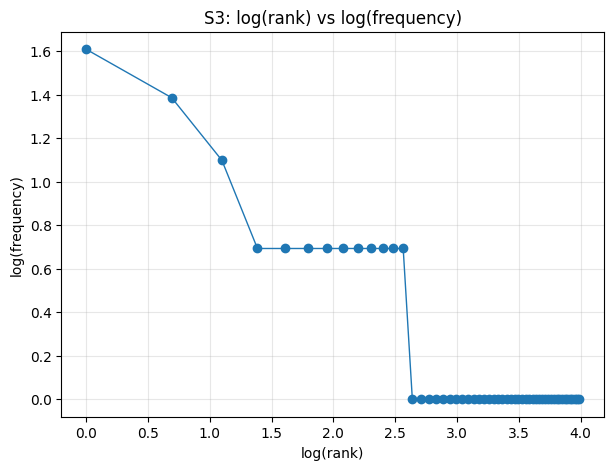


Top 5 bigrams — S1
[(('.', 'it'), 4), (('it', 'worked'), 4), (('worked', 'yesterday'), 4), (('yesterday', '.'), 4), (('.', 'i'), 3)]

Top 5 bigrams — S3
[(('worked', 'yesterday'), 4), (('latest', 'update'), 2), (('email', 'stopped'), 1), (('stopped', 'syncing'), 1), (('syncing', 'please'), 1)]


In [19]:
# Q5 — Corpus statistics
from collections import Counter
from nltk.util import bigrams
import math
import matplotlib.pyplot as plt

S1 = [t for p in processed.values() for t in p["tokens"]]
S2 = [t for t in S1 if not is_punct(t)]
S3 = [t for p in processed.values() for t in p["final"]]
S4 = [porter.stem(t) for t in S3]

def corpus_stats(tokens):
    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total else 0
    return total, unique, ttr

stats = pd.DataFrame(
    [corpus_stats(S1), corpus_stats(S2), corpus_stats(S3), corpus_stats(S4)],
    index=["S1: all tokens", "S2: no punctuation", "S3: final tokens", "S4: Porter stems"],
    columns=["total_tokens", "unique_tokens", "TTR"]
)

display(stats)

print("\nTop 10 words — S1")
print(Counter(S1).most_common(10))

print("\nTop 10 words — S3")
print(Counter(S3).most_common(10))

# Zipf-style plot for S3
freqs = sorted(Counter(S3).values(), reverse=True)
ranks = list(range(1, len(freqs) + 1))
plt.figure(figsize=(7, 5))
plt.plot([math.log(r) for r in ranks], [math.log(f) for f in freqs], marker="o", linewidth=1)
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("S3: log(rank) vs log(frequency)")
plt.grid(True, alpha=0.3)
plt.show()

print("\nTop 5 bigrams — S1")
print(Counter(bigrams(S1)).most_common(5))

print("\nTop 5 bigrams — S3")
print(Counter(bigrams(S3)).most_common(5))


**Answer:** TTR changes from S1 to S4 because S1 contains punctuation and function/stopword tokens and preserves the original word forms, while S4 removes punctuation and stopwords and then applies Porter stemming. Stemming maps several surface forms to the same stem, reducing the number of unique types relative to the token count, so the type-token ratio can change substantially.

## Submission note
Run **Runtime → Run all** in Colab. The notebook downloads the required NLTK resources in the first code cell, generates the dataset from your roll number, and then computes every answer from that dataset.

Your verified fingerprint is **38ADBD11** and the generated dataset contains **13 tickets**.